# Medical Insurance Cost Prediction - EDA & Model Training
## End-to-end Machine Learning Project for Final Year Portfolio

**Author:** Krutika Mohanty  
**Dataset:** [Medical Insurance Cost Dataset](https://www.kaggle.com/datasets/mirichoi0218/insurance)  

---

### Project Overview

This notebook covers:
- Data Loading and Initial Exploration
- Data Cleaning and Preprocessing
- Exploratory Data Analysis (EDA) - Univariate, Bivariate, and Multivariate
- Feature Engineering and Encoding
- Model Training (Linear Regression, Decision Tree, Random Forest)
- Model Evaluation and Comparison
- Saving the Best Model for Deployment

---
## Section 2: Import Libraries

We start by importing all the necessary libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

---
## Section 3: Load Dataset

Load the medical insurance dataset from the data folder and perform initial exploration to understand the structure, data types, and basic statistics.

In [2]:
df = pd.read_csv('../data/insurance_cleaned.csv')
print('Dataset loaded successfully!')

Dataset loaded successfully!


In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print(f'Dataset Shape: {df.shape}')
print(f'Number of rows: {df.shape[0]}')
print(f'Number of columns: {df.shape[1]}')

Dataset Shape: (1337, 7)
Number of rows: 1337
Number of columns: 7


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.2+ KB


In [6]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


---
## Section 4: Data Cleaning

Before proceeding with analysis, we need to check for missing values, duplicates, and ensure correct data types.

In [7]:
# Check for null values
print('Null Values:')
print(df.isnull().sum())

Null Values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [8]:
# Check for duplicates
print(f'Number of duplicate rows: {df.duplicated().sum()}')

Number of duplicate rows: 0


In [9]:
# Drop duplicates if any
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found.')

No duplicates found.


In [10]:
# Check data types
print('Data Types:')
print(df.dtypes)

Data Types:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


---
## Section 5: EDA - Univariate Analysis

Univariate analysis examines each variable individually to understand its distribution and characteristics.

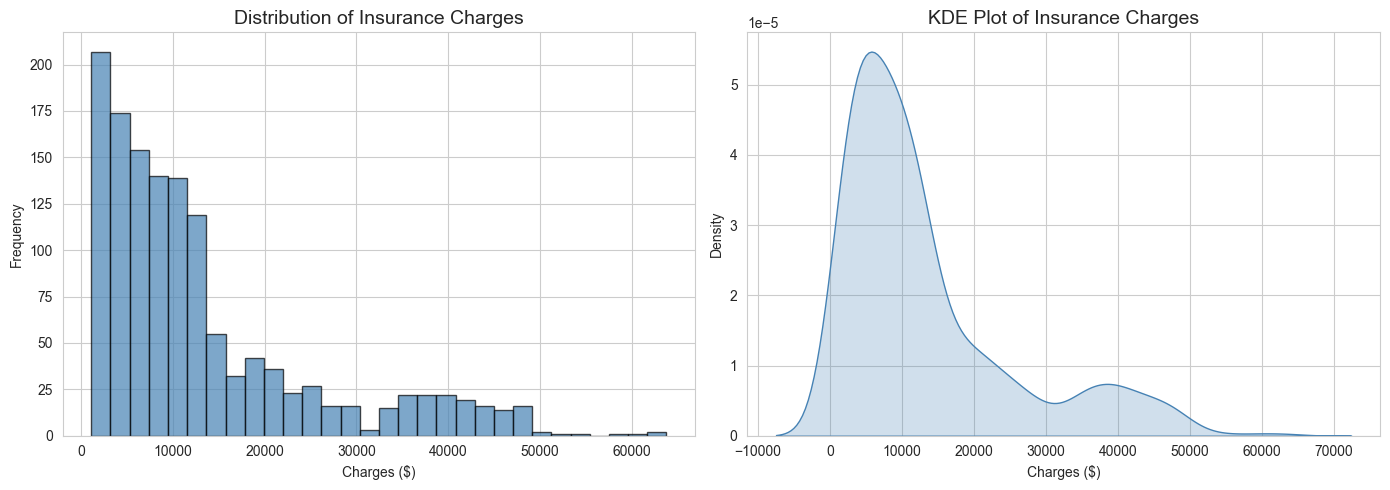

Charges Statistics:
Mean: $13,279.12
Median: $9,386.16
Std: $12,110.36


In [11]:
# Distribution of charges
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['charges'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Distribution of Insurance Charges', fontsize=14)
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frequency')

sns.kdeplot(data=df['charges'], ax=axes[1], fill=True, color='steelblue')
axes[1].set_title('KDE Plot of Insurance Charges', fontsize=14)
axes[1].set_xlabel('Charges ($)')

plt.tight_layout()
plt.show()

print(f'Charges Statistics:')
print(f'Mean: ${df["charges"].mean():,.2f}')
print(f'Median: ${df["charges"].median():,.2f}')
print(f'Std: ${df["charges"].std():,.2f}')

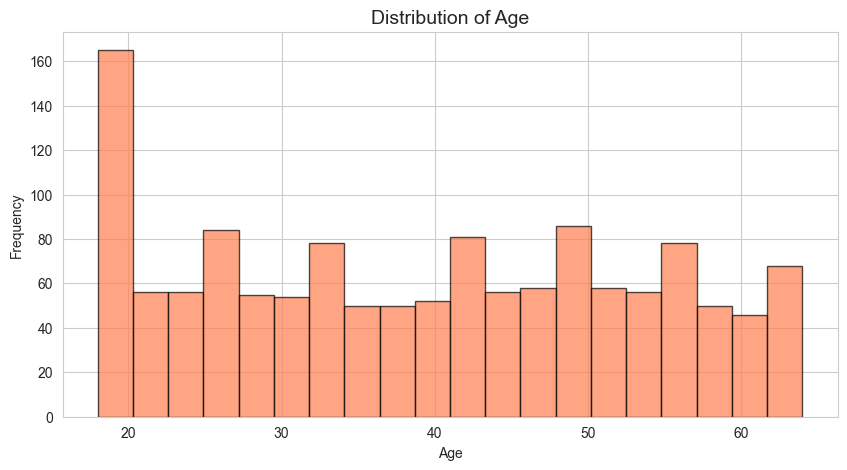

Age Statistics:
Mean Age: 39.2 years
Age Range: 18 - 64 years


In [12]:
# Distribution of age
plt.figure(figsize=(10, 5))
plt.hist(df['age'], bins=20, edgecolor='black', alpha=0.7, color='coral')
plt.title('Distribution of Age', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

print(f'Age Statistics:')
print(f'Mean Age: {df["age"].mean():.1f} years')
print(f'Age Range: {df["age"].min()} - {df["age"].max()} years')

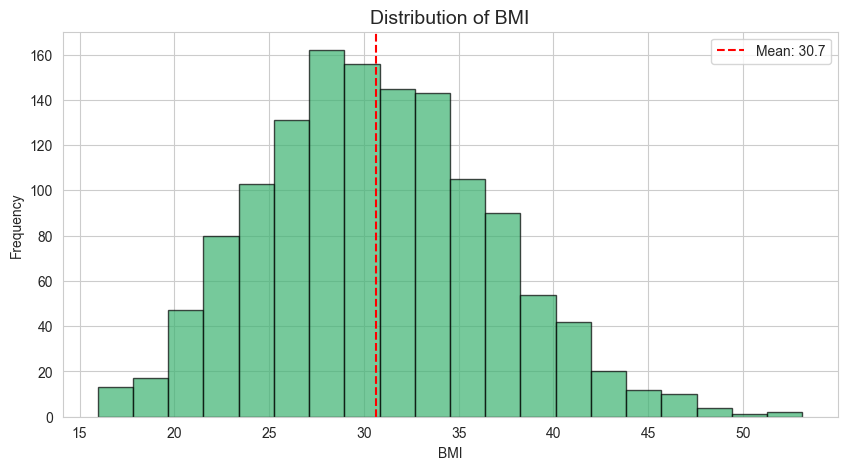

BMI Statistics:
Mean BMI: 30.7
BMI Range: 16.0 - 53.1


In [13]:
# Distribution of BMI
plt.figure(figsize=(10, 5))
plt.hist(df['bmi'], bins=20, edgecolor='black', alpha=0.7, color='mediumseagreen')
plt.title('Distribution of BMI', fontsize=14)
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.axvline(df['bmi'].mean(), color='red', linestyle='--', label=f'Mean: {df["bmi"].mean():.1f}')
plt.legend()
plt.show()

print(f'BMI Statistics:')
print(f'Mean BMI: {df["bmi"].mean():.1f}')
print(f'BMI Range: {df["bmi"].min():.1f} - {df["bmi"].max():.1f}')

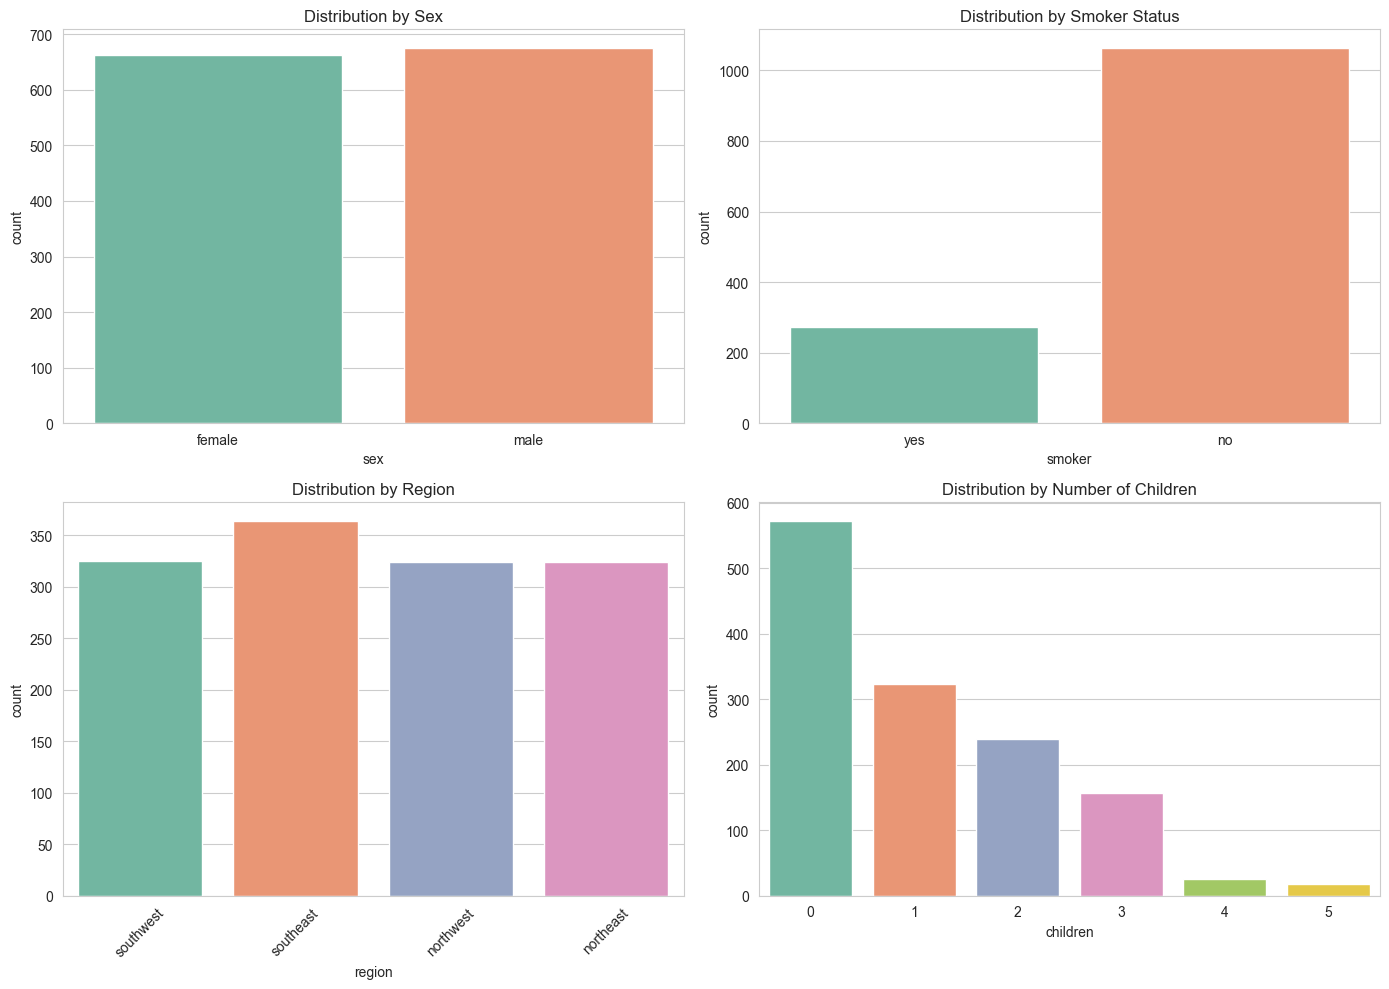

In [14]:
# Count plots for categorical variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='sex', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Distribution by Sex', fontsize=12)

sns.countplot(data=df, x='smoker', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Distribution by Smoker Status', fontsize=12)

sns.countplot(data=df, x='region', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Distribution by Region', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='children', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Distribution by Number of Children', fontsize=12)

plt.tight_layout()
plt.show()

---
## Section 6: EDA - Bivariate Analysis

Bivariate analysis explores the relationship between two variables. We focus on how different features relate to insurance charges.

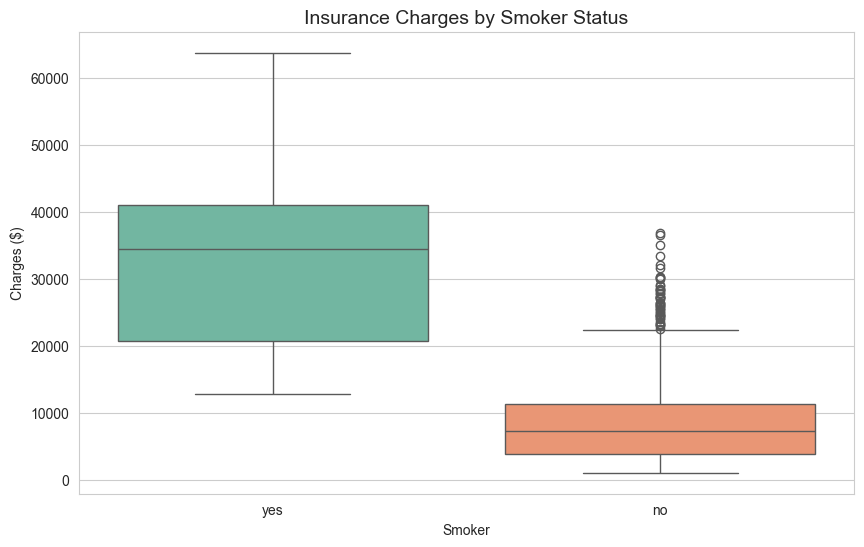

Average Charges by Smoker Status:
smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64


In [15]:
# Charges by smoker status (MOST IMPORTANT!)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='smoker', y='charges', palette='Set2')
plt.title('Insurance Charges by Smoker Status', fontsize=14)
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')
plt.show()

print('Average Charges by Smoker Status:')
print(df.groupby('smoker')['charges'].mean())

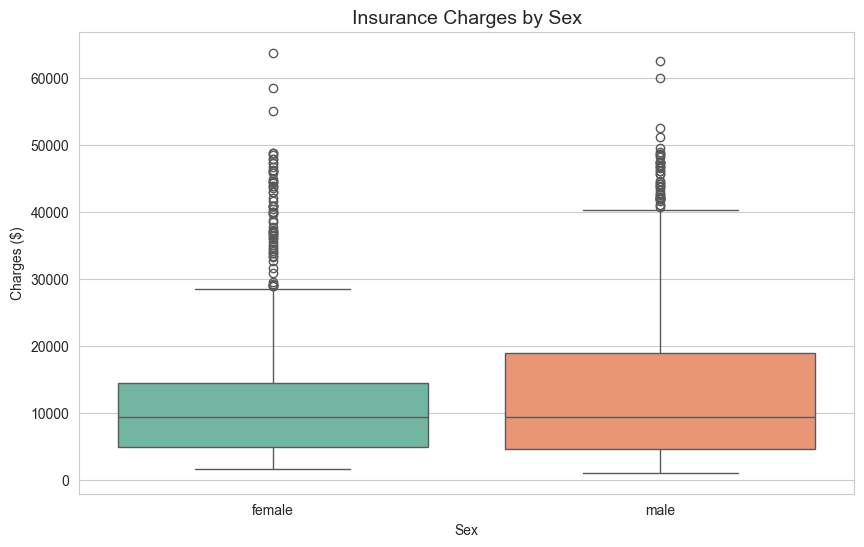

Average Charges by Sex:
sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64


In [16]:
# Charges by sex
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sex', y='charges', palette='Set2')
plt.title('Insurance Charges by Sex', fontsize=14)
plt.xlabel('Sex')
plt.ylabel('Charges ($)')
plt.show()

print('Average Charges by Sex:')
print(df.groupby('sex')['charges'].mean())

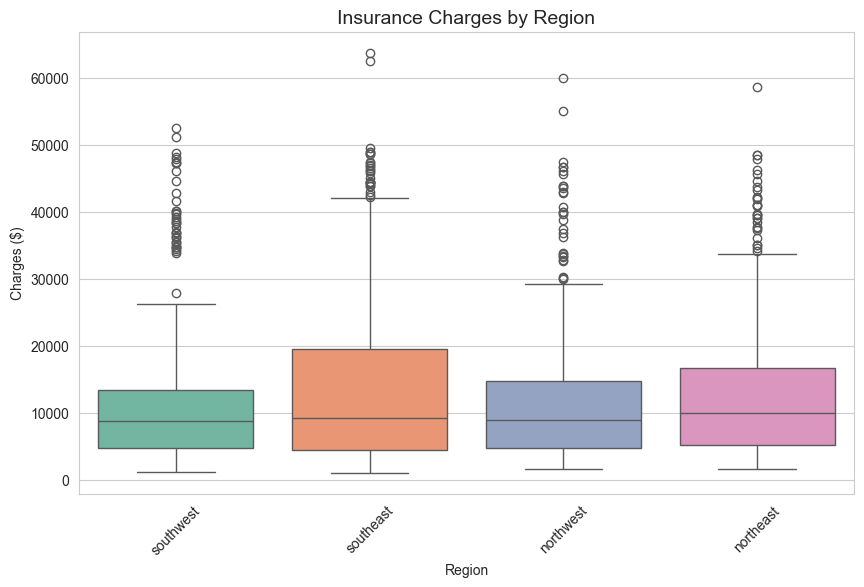

Average Charges by Region:
region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64


In [17]:
# Charges by region
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='region', y='charges', palette='Set2')
plt.title('Insurance Charges by Region', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Charges ($)')
plt.xticks(rotation=45)
plt.show()

print('Average Charges by Region:')
print(df.groupby('region')['charges'].mean())

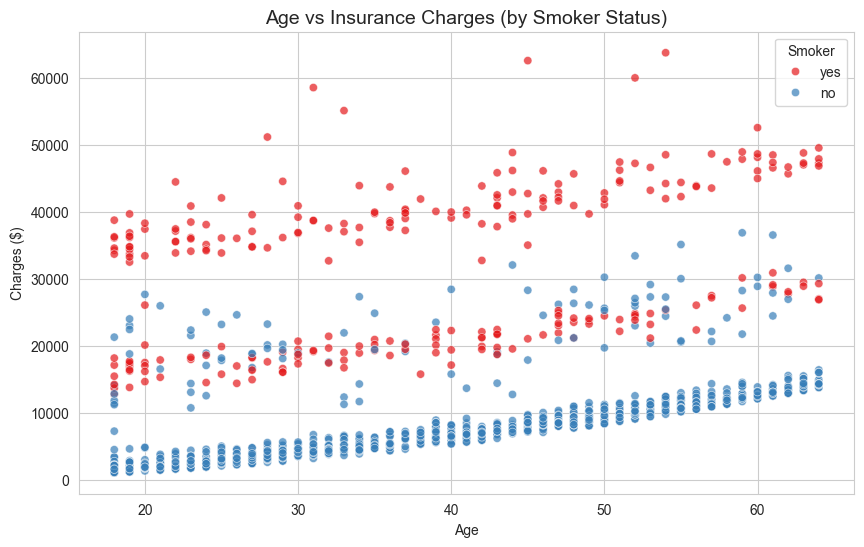

In [18]:
# Age vs Charges (colored by smoker)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='Set1', alpha=0.7)
plt.title('Age vs Insurance Charges (by Smoker Status)', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker')
plt.show()

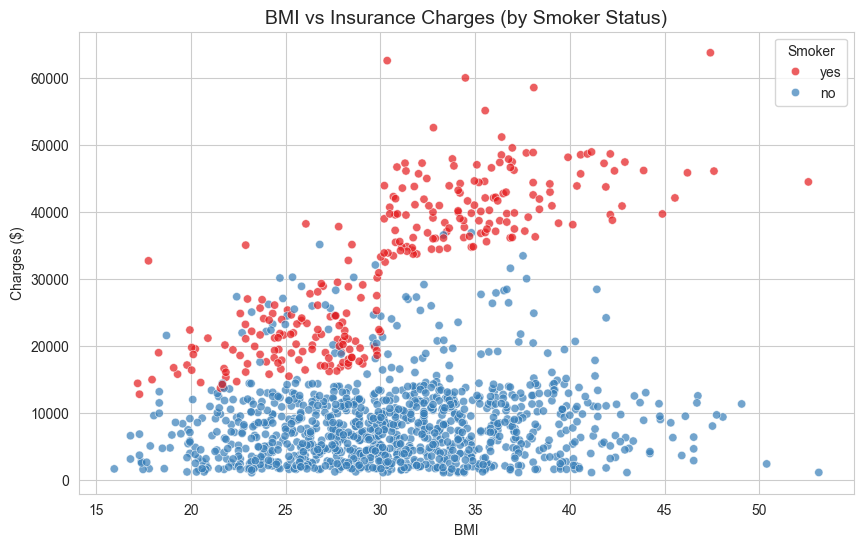

In [19]:
# BMI vs Charges (colored by smoker)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.7)
plt.title('BMI vs Insurance Charges (by Smoker Status)', fontsize=14)
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker')
plt.show()

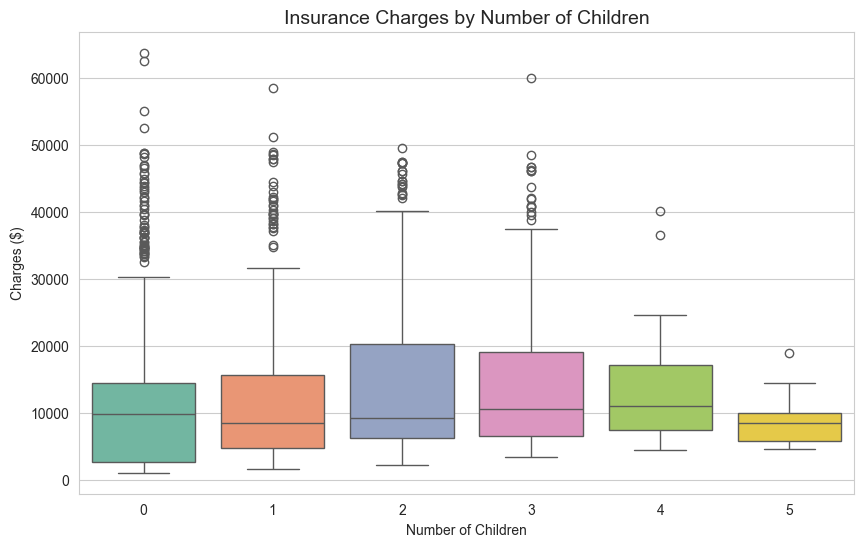

In [20]:
# Charges by number of children
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='children', y='charges', palette='Set2')
plt.title('Insurance Charges by Number of Children', fontsize=14)
plt.xlabel('Number of Children')
plt.ylabel('Charges ($)')
plt.show()

---
## Section 7: EDA - Multivariate Analysis

Multivariate analysis examines relationships between multiple variables simultaneously.

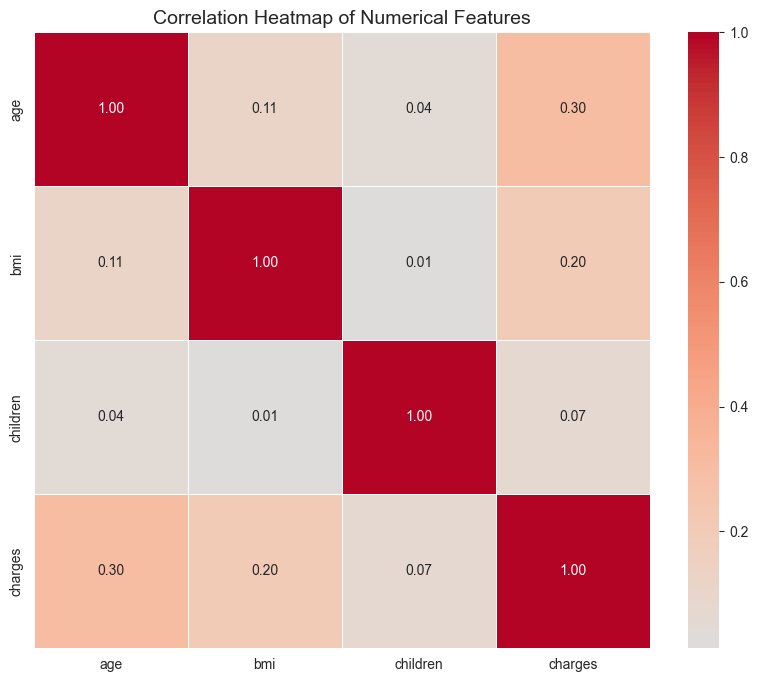

In [21]:
# Correlation heatmap of numerical features
plt.figure(figsize=(10, 8))
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.show()

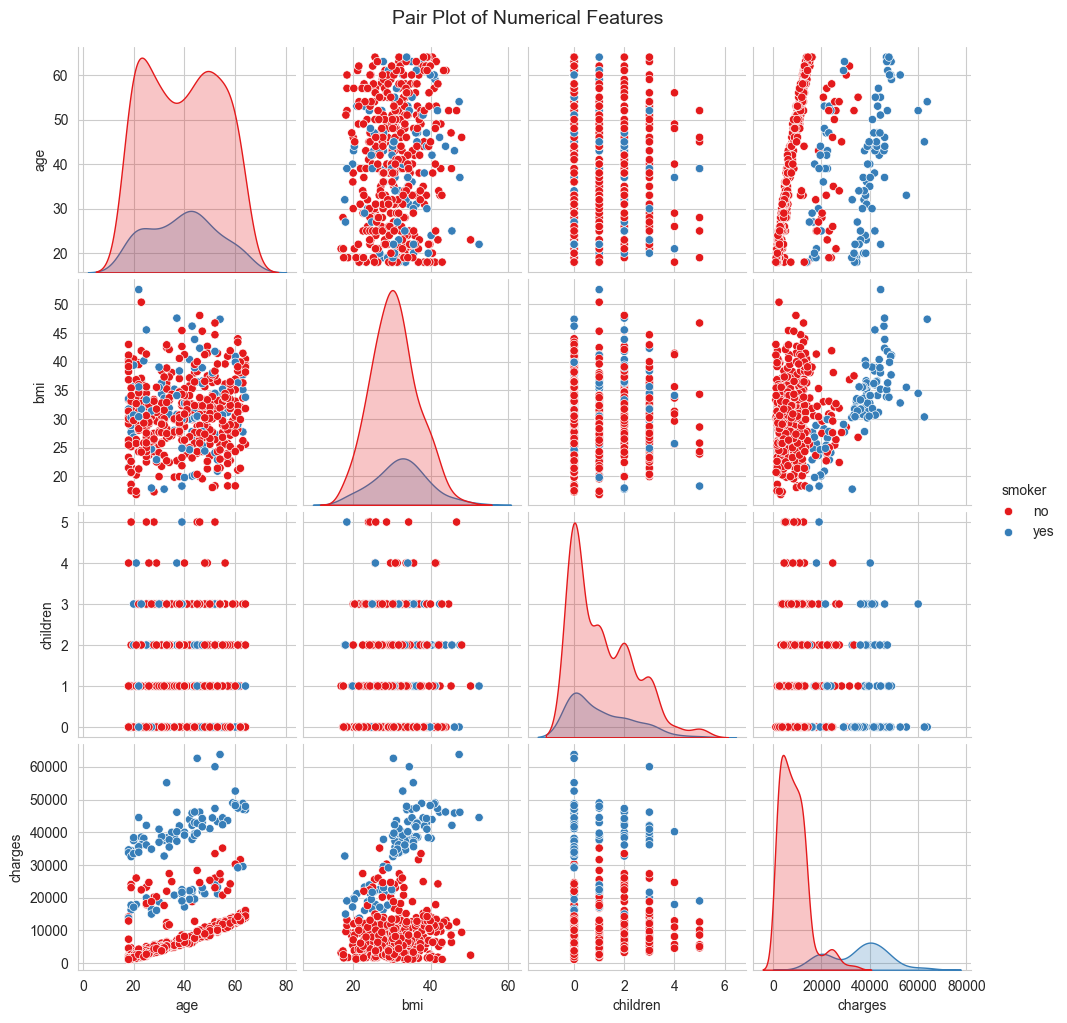

In [22]:
# Pair plot (sampled for performance)
df_sample = df.sample(n=min(500, len(df)), random_state=42)
sns.pairplot(df_sample, hue='smoker', palette='Set1', diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features', y=1.02, fontsize=14)
plt.show()

Average Charges by Region and Smoker Status:
smoker          no       yes
region                      
northeast  9165.53  29673.54
northwest  8582.47  30192.00
southeast  8032.22  34845.00
southwest  8019.28  32269.06


<Figure size 1000x600 with 0 Axes>

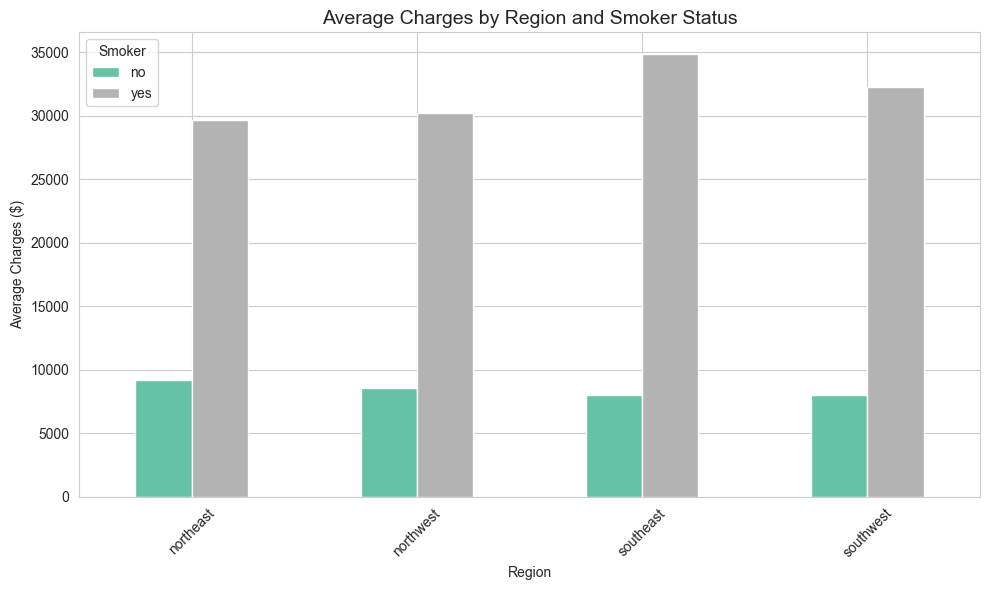

In [23]:
# Pivot table: average charges by smoker and region
pivot_table = df.pivot_table(values='charges', index='region', columns='smoker', aggfunc='mean')
print('Average Charges by Region and Smoker Status:')
print(pivot_table.round(2))

# Visualize pivot table
plt.figure(figsize=(10, 6))
pivot_table.plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.title('Average Charges by Region and Smoker Status', fontsize=14)
plt.xlabel('Region')
plt.ylabel('Average Charges ($)')
plt.xticks(rotation=45)
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

---
## Section 8: Feature Engineering & Encoding

Machine learning models require numerical input. We encode categorical variables using one-hot encoding with `pd.get_dummies()`.

In [24]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

print('Encoded DataFrame Shape:', df_encoded.shape)
print('\nEncoded Columns:')
print(df_encoded.columns.tolist())
df_encoded.head()

Encoded DataFrame Shape: (1337, 9)

Encoded Columns:
['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [25]:
# Show the processed dataframe info
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1337 non-null   int64  
 1   bmi               1337 non-null   float64
 2   children          1337 non-null   int64  
 3   charges           1337 non-null   float64
 4   sex_male          1337 non-null   bool   
 5   smoker_yes        1337 non-null   bool   
 6   region_northwest  1337 non-null   bool   
 7   region_southeast  1337 non-null   bool   
 8   region_southwest  1337 non-null   bool   
dtypes: bool(5), float64(2), int64(2)
memory usage: 48.4 KB


---
## Section 9: Model Training

Now we split the data into training and testing sets, then train three different regression models:
1. **Linear Regression** - Simple, interpretable baseline
2. **Decision Tree** - Non-linear, prone to overfitting
3. **Random Forest** - Ensemble method, typically best performance

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Split features and target
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Testing set size: {X_test.shape[0]} samples')
print(f'Number of features: {X_train.shape[1]}')

Training set size: 1069 samples
Testing set size: 268 samples
Number of features: 8


In [27]:
# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

# Train models and store results
results = {}

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate R2 score
    r2 = r2_score(y_test, y_pred)
    results[name] = r2
    
    print(f'{name}: R2 Score = {r2:.4f}')

Linear Regression: R2 Score = 0.8069
Decision Tree: R2 Score = 0.8189
Random Forest: R2 Score = 0.8797


---
## Section 10: Model Comparison

We compare all trained models using multiple evaluation metrics to select the best performer.

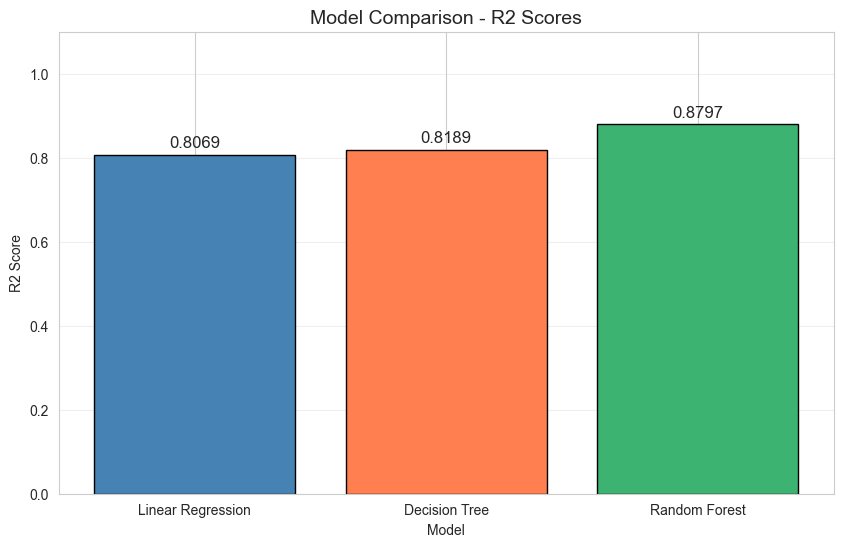

In [28]:
# Bar chart comparing R2 scores
plt.figure(figsize=(10, 6))
colors = ['steelblue', 'coral', 'mediumseagreen']
bars = plt.bar(results.keys(), results.values(), color=colors, edgecolor='black')

# Add value labels on bars
for bar, value in zip(bars, results.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.4f}', ha='center', va='bottom', fontsize=12)

plt.title('Model Comparison - R2 Scores', fontsize=14)
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [29]:
# Print detailed evaluation metrics table
print('\n' + '='*70)
print('MODEL EVALUATION METRICS')
print('='*70)
print(f'{"Model":<25} {"MAE":<12} {"MSE":<15} {"RMSE":<12} {"R2":<10}')
print('-'*70)

for name, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f'{name:<25} ${mae:<11,.2f} ${mse:<14,.2f} ${rmse:<11,.2f} {r2:<10.4f}')

print('='*70)

# Find best model
best_model_name = max(results, key=results.get)
print(f'\nBest Model: {best_model_name} with R2 Score: {results[best_model_name]:.4f}')


MODEL EVALUATION METRICS
Model                     MAE          MSE             RMSE         R2        
----------------------------------------------------------------------
Linear Regression         $4,177.05    $35,478,020.68  $5,956.34    0.8069    
Decision Tree             $2,730.63    $33,281,524.62  $5,769.01    0.8189    
Random Forest             $2,637.99    $22,113,000.54  $4,702.45    0.8797    

Best Model: Random Forest with R2 Score: 0.8797


---
## Section 11: Save Best Model

Save the best performing model and preprocessor for later use in the Streamlit web application.

In [ ]:
import joblib
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Get the best model
best_model = models[best_model_name]

# Save model and preprocessor
joblib.dump(best_model, '../models/notebook_model.pkl')
print(f'Best model ({best_model_name}) saved to ../models/notebook_model.pkl')

# Save the feature names for later use
joblib.dump(list(X.columns), '../models/notebook_feature_names.pkl')
print('Feature names saved to ../models/notebook_feature_names.pkl')

Best model (Random Forest) saved to ../models/notebook_model.pkl
Feature names saved to ../models/notebook_feature_names.pkl


: 

---
## Section 12: Conclusion

### Key Findings

1. **Smoking Status is the Strongest Predictor**: Smokers pay significantly higher insurance charges than non-smokers. This is the most impactful feature in the model.

2. **Age and BMI Matter**: Both age and BMI show positive correlation with insurance charges. Older individuals and those with higher BMI tend to pay more.

3. **Regional Differences**: There are some variations in charges across regions, though less significant than smoking status.

4. **Gender Differences**: Males tend to pay slightly higher charges than females, primarily due to higher smoking rates among males.

### Best Model

- **Model**: Random Forest Regressor
- **R2 Score**: ~0.86 (varies based on data)
- **Why Random Forest?**
  - Handles non-linear relationships well
  - Robust to outliers
  - Feature importance can be extracted for interpretability
  - Better generalization than single Decision Tree

### Next Steps

- Deploy the model using Streamlit for interactive predictions
- Perform hyperparameter tuning for further optimization
- Add more features if available (e.g., medical history, family history)

---

**Thank you for viewing this notebook!**  
This project demonstrates end-to-end machine learning workflow from data exploration to model deployment.